<a href="https://colab.research.google.com/github/MYoussef885/Rock_VS_Mine_Prediction/blob/main/Rock_vs_Mine_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Collection and Data Processing

In [2]:
#loading the dataset to a pandas dataframe
sonar_data = pd.read_csv('/content/Copy of sonar data.csv', header=None)

In [3]:
sonar_data.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [4]:
#number of rows and columns
sonar_data.shape

(208, 61)

In [5]:
sonar_data.describe() #describe --> statistical measures of the data

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [6]:
sonar_data[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

M --> Mine
R --> Rock

In [7]:
sonar_data.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


## Exploratory Data Analysis & Visualizations

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

Checking for missing values (an important step before training any model).

In [9]:
#check for missing values in the dataset
sonar_data.isnull().sum().sum()

np.int64(0)

Class distribution: how many Rock (R) vs Mine (M) samples are in the dataset.

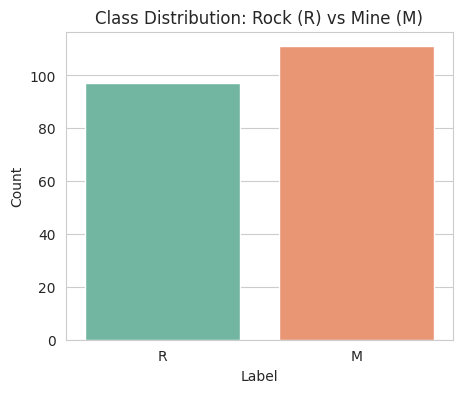

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x=sonar_data[60], hue=sonar_data[60], palette='Set2', legend=False)
plt.title('Class Distribution: Rock (R) vs Mine (M)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

Average sonar signal strength per frequency band, compared across the two classes. This shows which frequency bands tend to separate rocks from mines.

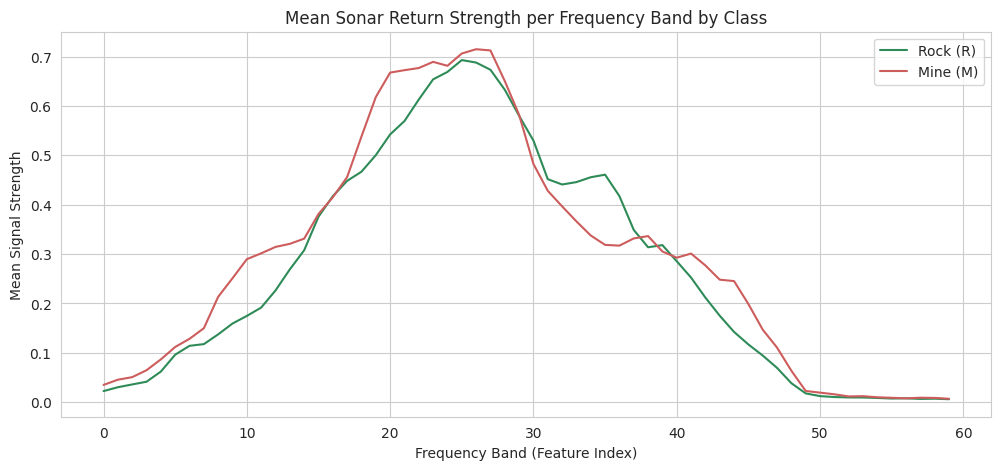

In [11]:
class_means = sonar_data.groupby(60).mean()

plt.figure(figsize=(12,5))
plt.plot(class_means.columns, class_means.loc['R'], label='Rock (R)', color='seagreen')
plt.plot(class_means.columns, class_means.loc['M'], label='Mine (M)', color='indianred')
plt.title('Mean Sonar Return Strength per Frequency Band by Class')
plt.xlabel('Frequency Band (Feature Index)')
plt.ylabel('Mean Signal Strength')
plt.legend()
plt.show()

Distribution of a few individual features split by class, to see how separable they are.

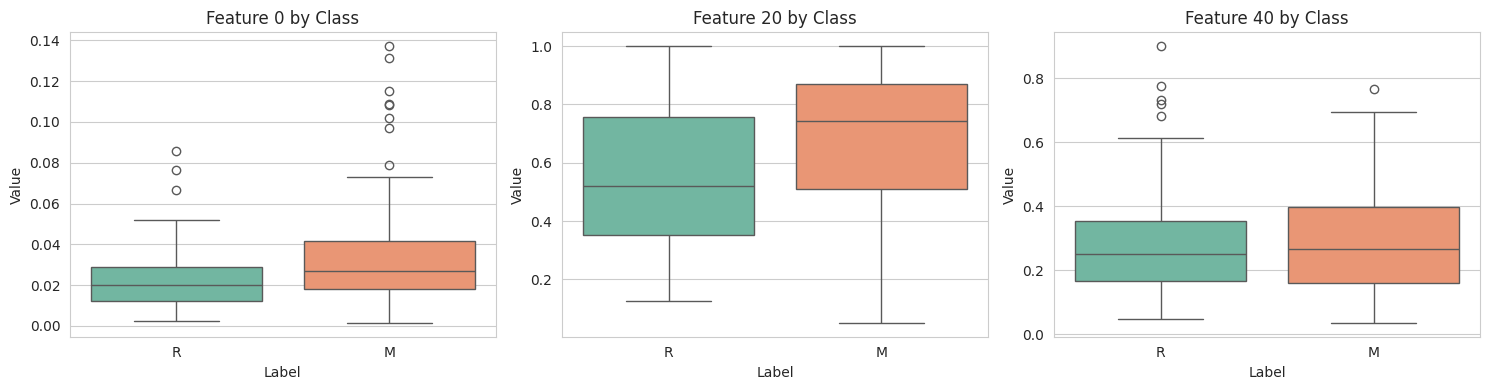

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, feature in zip(axes, [0, 20, 40]):
    sns.boxplot(x=sonar_data[60], y=sonar_data[feature], hue=sonar_data[60], palette='Set2', legend=False, ax=ax)
    ax.set_title(f'Feature {feature} by Class')
    ax.set_xlabel('Label')
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

Correlation heatmap across all 60 sonar features (helps spot multicollinearity).

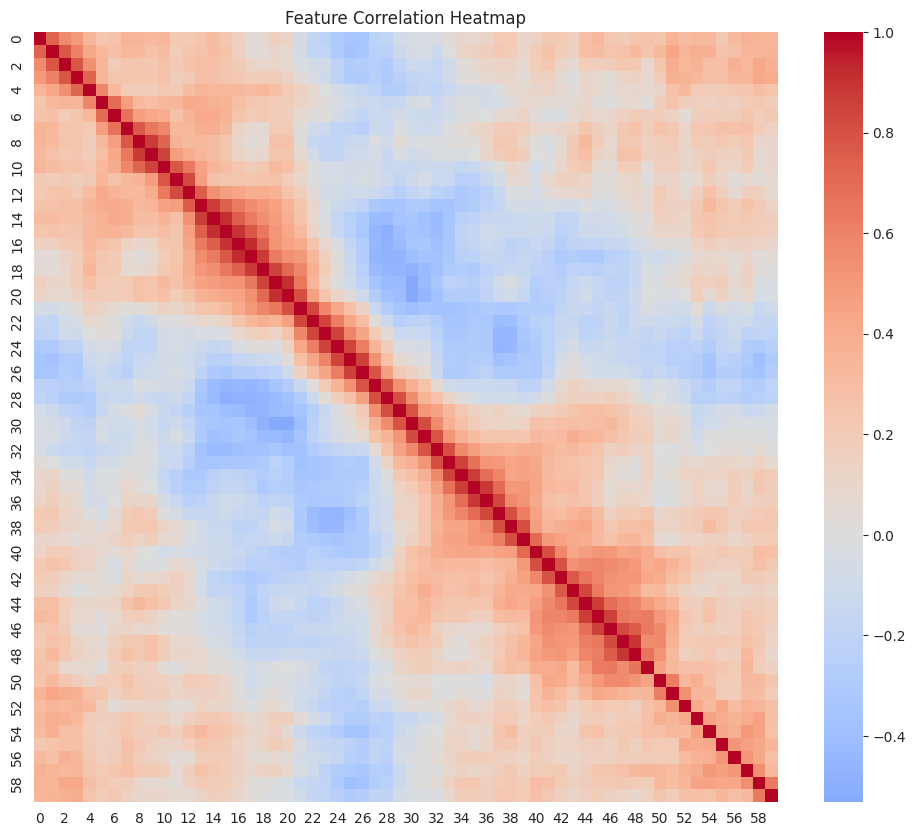

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(sonar_data.drop(columns=60).corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

A 2D PCA projection to visually check how separable Rocks and Mines are once dimensionality is reduced.

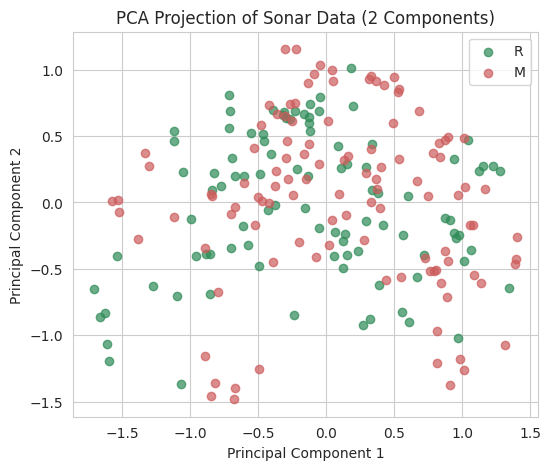

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(sonar_data.drop(columns=60))

plt.figure(figsize=(6,5))
for label, color in zip(['R', 'M'], ['seagreen', 'indianred']):
    mask = sonar_data[60] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.7, color=color)
plt.title('PCA Projection of Sonar Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [15]:
#separating data and Labels
X = sonar_data.drop(columns=60)
Y = sonar_data[60]

In [16]:
print(X)
print(Y)

         0       1       2       3       4       5       6       7       8   \
0    0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1    0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2    0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3    0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4    0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
204  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
205  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
206  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
207  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

         9   ...      50      51      52      53   

Training and test data

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, stratify= Y, random_state=1)

In [18]:
print(X.shape, X_train.shape, X_test.shape)

(208, 60) (187, 60) (21, 60)


In [19]:
print(X_train)
print(Y_train)

         0       1       2       3       4       5       6       7       8   \
115  0.0414  0.0436  0.0447  0.0844  0.0419  0.1215  0.2002  0.1516  0.0818   
38   0.0123  0.0022  0.0196  0.0206  0.0180  0.0492  0.0033  0.0398  0.0791   
56   0.0152  0.0102  0.0113  0.0263  0.0097  0.0391  0.0857  0.0915  0.0949   
123  0.0270  0.0163  0.0341  0.0247  0.0822  0.1256  0.1323  0.1584  0.2017   
18   0.0270  0.0092  0.0145  0.0278  0.0412  0.0757  0.1026  0.1138  0.0794   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
140  0.0412  0.1135  0.0518  0.0232  0.0646  0.1124  0.1787  0.2407  0.2682   
5    0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   
154  0.0117  0.0069  0.0279  0.0583  0.0915  0.1267  0.1577  0.1927  0.2361   
131  0.1150  0.1163  0.0866  0.0358  0.0232  0.1267  0.2417  0.2661  0.4346   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   

         9   ...      50      51      52      53   

Model Training --> Logistic Regression

In [20]:
model = LogisticRegression()

In [21]:
#training the logistic regression model with taining data
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Model Evaluation

In [22]:
#accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [23]:
print('Accuracy on training data :', training_data_accuracy)

Accuracy on training data : 0.8342245989304813


In [24]:
#accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [25]:
print('Accuracy on test data :', test_data_accuracy)

Accuracy on test data : 0.7619047619047619


## Deeper Model Evaluation

Confusion matrices for the training and test sets, to see exactly which classes are being confused.

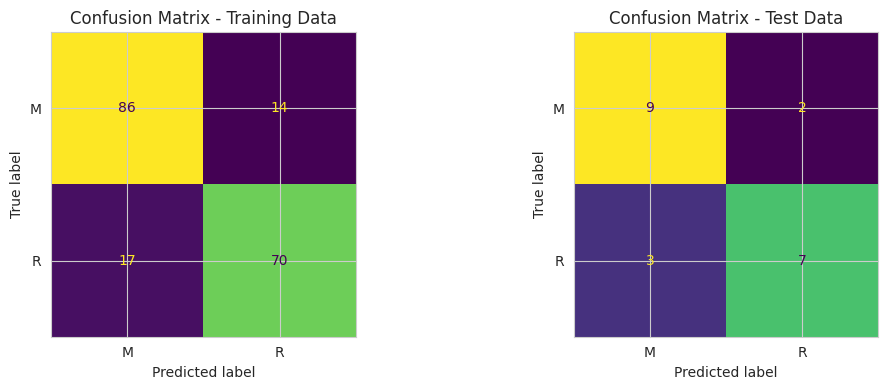

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11,4))

cm_train = confusion_matrix(Y_train, X_train_prediction, labels=model.classes_)
ConfusionMatrixDisplay(cm_train, display_labels=model.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix - Training Data')

cm_test = confusion_matrix(Y_test, X_test_prediction, labels=model.classes_)
ConfusionMatrixDisplay(cm_test, display_labels=model.classes_).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix - Test Data')

plt.tight_layout()
plt.show()

Precision, recall and F1-score per class on the test set (accuracy alone can hide class-level weaknesses).

In [27]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           M       0.75      0.82      0.78        11
           R       0.78      0.70      0.74        10

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.76      0.76      0.76        21



ROC curve and AUC score, which show how well the model separates the two classes across all thresholds.

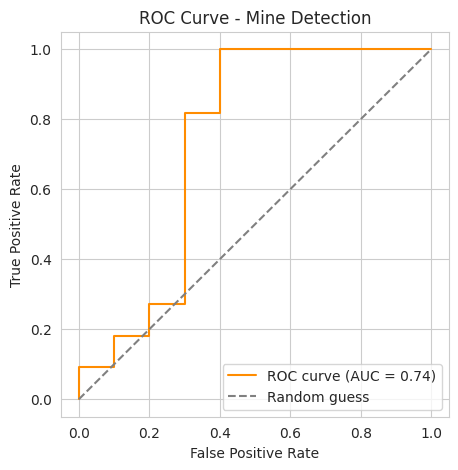

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

Y_test_prob = model.predict_proba(X_test)[:, list(model.classes_).index('M')]
Y_test_binary = (Y_test == 'M').astype(int)

fpr, tpr, thresholds = roc_curve(Y_test_binary, Y_test_prob)
auc_score = roc_auc_score(Y_test_binary, Y_test_prob)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Mine Detection')
plt.legend()
plt.show()

Cross-validation gives a more reliable estimate of how the model performs on unseen data than a single train/test split, since the dataset is quite small (only 208 samples).

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X, Y, cv=5)
print('Cross-validation scores:', cv_scores)
print('Mean CV accuracy: %.4f (+/- %.4f)' % (cv_scores.mean(), cv_scores.std()))

Cross-validation scores: [0.45238095 0.76190476 0.61904762 0.82926829 0.48780488]
Mean CV accuracy: 0.6301 (+/- 0.1476)


Making a Predicting system

In [30]:
input_data = (0.0261,0.0266,0.0223,0.0749,0.1364,0.1513,0.1316,0.1654,0.1864,0.2013,0.2890,0.3650,0.3510,0.3495,0.4325,0.5398,0.6237,0.6876,0.7329,0.8107,0.8396,0.8632,0.8747,0.9607,0.9716,0.9121,0.8576,0.8798,0.7720,0.5711,0.4264,0.2860,0.3114,0.2066,0.1165,0.0185,0.1302,0.2480,0.1637,0.1103,0.2144,0.2033,0.1887,0.1370,0.1376,0.0307,0.0373,0.0606,0.0399,0.0169,0.0135,0.0222,0.0175,0.0127,0.0022,0.0124,0.0054,0.0021,0.0028,0.0023)

#changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the np array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)
prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]=='R'):
  print('the object is a Rock')
else:
  print('the object is a Mine')

['M']
the object is a Mine
